<a href="https://colab.research.google.com/github/0-0Coral/543/blob/main/DATA543_Heat_Mortality_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# 看看 DATA543_Project 文件夹里有什么
project_path = '/content/drive/MyDrive/DATA543_Project'
print("项目主文件夹的内容：")
print(os.listdir(project_path))

# 看看 data_raw 里有什么
raw_path = '/content/drive/MyDrive/DATA543_Project/data_raw'
print("\ndata_raw 里的文件：")
for f in os.listdir(raw_path):
    print(f"  - {f}")

项目主文件夹的内容：
['data_raw', 'data_processed', 'figures', 'scripts']

data_raw 里的文件：
  - cdc_mortality_monthly_age70plus_2010_2020.csv
  - cdc_mortality_annual_age70plus_2010_2020.csv
  - tl_2025_us_county.shp
  - tl_2025_us_county.shx
  - tl_2025_us_county.dbf
  - tl_2025_us_county.prj


In [ ]:
# 1. 创建一个 risk_question.md 文件
# 2. 把上面的Risk Question内容写进去
# 3. 保存到 DATA543_Project / scripts / 文件夹里

risk_question_content = """# DATA543 Project: Risk Question

## Project Title
**Extreme Heat and Elderly Mortality: A State-Level Analysis of the United States, 2010-2020**

## 1. Background and Motivation

Extreme heat is one of the deadliest weather-related hazards in the United States,
and its impact is disproportionately felt by older adults. According to the World
Health Organization, heat-related mortality among adults aged 65 and over has
increased by approximately 85% between 2000-2004 and 2017-2021. As climate change
drives more frequent and intense heat waves, understanding how extreme heat
translates into mortality risk—particularly for vulnerable elderly populations—has
become a critical public health priority.

## 2. Research Questions

### Primary Research Question
How does the frequency of extreme heat days affect mortality rates among adults
aged 70 and older across U.S. states from 2010 to 2020?

### Secondary Research Questions
1. Which U.S. states exhibit the highest vulnerability to heat-related mortality?
2. How has the relationship between extreme heat exposure and elderly mortality
   evolved over the past decade?
3. Does the heat-mortality relationship show seasonal heterogeneity?

## 3. Risk Framework

| Component | Definition | Data Source |
|-----------|-----------|-------------|
| **Hazard** | Annual count of days with daily maximum temperature > 90°F | GRIDMET reanalysis (4km grid aggregated to state) |
| **Exposure** | Population aged 70 and older | CDC WONDER (Multiple Cause of Death) |
| **Vulnerability** | All-cause mortality rate per 100,000 elderly adults | CDC WONDER |

## 4. Hypotheses

- **H1**: States with more annual extreme heat days (>90°F) will show higher
  elderly mortality rates.
- **H2**: The heat-mortality relationship will be strongest in summer months.
- **H3**: States with less historical heat exposure may show heightened
  vulnerability per heat day, due to lower acclimatization.

## 5. Methodological Approach

- **Linear Regression**: Quantify the average effect of extreme heat days
  on log-transformed mortality rate.
- **Poisson Regression**: Model death counts with population offset and
  state fixed effects.
- **Geographic Visualization**: Map state-level heat exposure and mortality
  patterns.
"""

# 写入文件
output_path = '/content/drive/MyDrive/DATA543_Project/scripts/risk_question.md'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(risk_question_content)

print(f"✓ Risk Question 文件已保存到：")
print(f"  {output_path}")
print(f"\n文件大小：{len(risk_question_content)} 字符")

✓ Risk Question 文件已保存到：
  /content/drive/MyDrive/DATA543_Project/scripts/risk_question.md

文件大小：2277 字符


In [ ]:
# ===== Step 2.1: 安装必要的Python库 =====
# 解释：
# - netCDF4: 读取GRIDMET的.nc数据文件（NetCDF格式是气象学标准）
# - geopandas: 处理地理空间数据（shapefile）
# - 其他库Colab已经预装

!pip install netCDF4 geopandas -q

print("✓ 库安装完成")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 45.3 MB/s eta 0:00:00
✓ 库安装完成


步骤1：加载县级shapefile...
  ✓ 加载完成: 3235 个县

步骤2：把县合并成州...
  ✓ 合并完成: 56 个州

步骤3：保存州级shapefile...
  ✓ 保存到: /content/drive/MyDrive/DATA543_Project/data_processed/us_states_geometry.shp

步骤4：画地图验证...


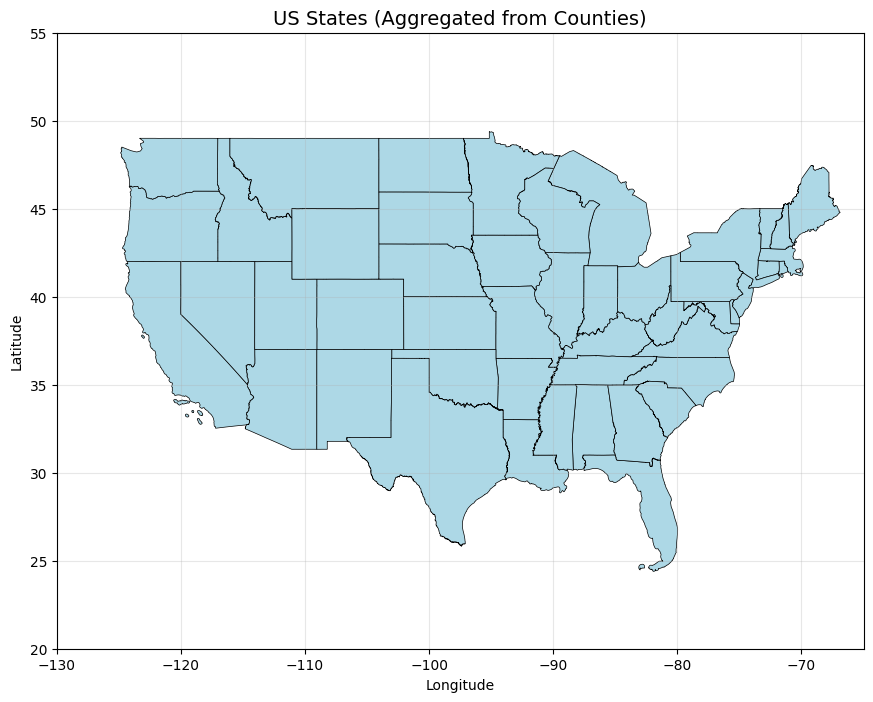

  ✓ 地图保存到: /content/drive/MyDrive/DATA543_Project/figures/check_us_states_map.png

✓ Step 2.2 完成！共有 51 个州


In [ ]:
# ===== Step 2.2: 准备州级地理数据 =====
# 解释：
# 1. 读取课程提供的县级shapefile（tl_2025_us_county.shp）
# 2. 用 dissolve 函数把"县"合并成"州"
# 3. 保存为新的州级shapefile
# 4. 画地图验证

import geopandas as gpd
import matplotlib.pyplot as plt

# === 路径设置 ===
# 用变量定义路径，代码更整洁
DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'
DATA_RAW_DIR = f'{DRIVE_ROOT}/data_raw'
DATA_PROCESSED_DIR = f'{DRIVE_ROOT}/data_processed'
FIGURES_DIR = f'{DRIVE_ROOT}/figures'

# === 加载县级 shapefile ===
print("步骤1：加载县级shapefile...")
counties_gdf = gpd.read_file(f'{DATA_RAW_DIR}/tl_2025_us_county.shp')
counties_gdf = counties_gdf.to_crs(epsg=4326)  # 转换为标准WGS84坐标系
print(f"  ✓ 加载完成: {len(counties_gdf)} 个县")

# === 县合并成州 ===
print("\n步骤2：把县合并成州...")
states_gdf = counties_gdf.dissolve(by='STATEFP').reset_index()
print(f"  ✓ 合并完成: {len(states_gdf)} 个州")

# === 添加州名 ===
# FIPS code 是美国官方的州编号系统
state_fips_to_name = {
    '01': 'Alabama',     '02': 'Alaska',          '04': 'Arizona',         '05': 'Arkansas',
    '06': 'California',  '08': 'Colorado',        '09': 'Connecticut',     '10': 'Delaware',
    '11': 'District of Columbia', '12': 'Florida','13': 'Georgia',         '15': 'Hawaii',
    '16': 'Idaho',       '17': 'Illinois',        '18': 'Indiana',         '19': 'Iowa',
    '20': 'Kansas',      '21': 'Kentucky',        '22': 'Louisiana',       '23': 'Maine',
    '24': 'Maryland',    '25': 'Massachusetts',   '26': 'Michigan',        '27': 'Minnesota',
    '28': 'Mississippi', '29': 'Missouri',        '30': 'Montana',         '31': 'Nebraska',
    '32': 'Nevada',      '33': 'New Hampshire',   '34': 'New Jersey',      '35': 'New Mexico',
    '36': 'New York',    '37': 'North Carolina',  '38': 'North Dakota',    '39': 'Ohio',
    '40': 'Oklahoma',    '41': 'Oregon',          '42': 'Pennsylvania',    '44': 'Rhode Island',
    '45': 'South Carolina','46':'South Dakota',   '47': 'Tennessee',       '48': 'Texas',
    '49': 'Utah',        '50': 'Vermont',         '51': 'Virginia',        '53': 'Washington',
    '54': 'West Virginia','55':'Wisconsin',       '56': 'Wyoming'
}
states_gdf['State'] = states_gdf['STATEFP'].map(state_fips_to_name)
states_gdf = states_gdf[states_gdf['State'].notna()]  # 去掉海外领地
states_gdf = states_gdf[['STATEFP', 'State', 'geometry']].reset_index(drop=True)

# === 保存到 data_processed ===
print("\n步骤3：保存州级shapefile...")
states_output_path = f'{DATA_PROCESSED_DIR}/us_states_geometry.shp'
states_gdf.to_file(states_output_path)
print(f"  ✓ 保存到: {states_output_path}")

# === 画地图验证 ===
print("\n步骤4：画地图验证...")
fig, ax = plt.subplots(figsize=(14, 8))
states_gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=0.5)
ax.set_title('US States (Aggregated from Counties)', fontsize=14)
ax.set_xlim(-130, -65)  # 只看本土+夏威夷+阿拉斯加部分
ax.set_ylim(20, 55)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)

# 保存图到 figures
fig_path = f'{FIGURES_DIR}/check_us_states_map.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"  ✓ 地图保存到: {fig_path}")

print(f"\n{'='*50}")
print(f"✓ Step 2.2 完成！共有 {len(states_gdf)} 个州")
print(f"{'='*50}")

In [ ]:
# ===== Step 2.3: 下载并处理第1年（2010）的GRIDMET数据 =====
# 这一步约5-10分钟（主要是下载时间）

import os
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import netCDF4 as nc
from shapely.geometry import Point
import time

# === 路径设置 ===
DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'
DATA_PROCESSED_DIR = f'{DRIVE_ROOT}/data_processed'

# Colab临时存储目录（用来放NetCDF原始文件，处理完会删）
COLAB_TEMP_DIR = '/content/temp_gridmet'
os.makedirs(COLAB_TEMP_DIR, exist_ok=True)

# === 第1步：下载 tmmx_2010.nc ===
print("="*60)
print("步骤1：下载 tmmx_2010.nc (约500MB)")
print("="*60)

year = 2010
url = f'https://www.northwestknowledge.net/metdata/data/tmmx_{year}.nc'
local_path = f'{COLAB_TEMP_DIR}/tmmx_{year}.nc'

if not os.path.exists(local_path):
    print(f"开始下载 {year} 年数据...")
    start_time = time.time()

    response = requests.get(url, stream=True, timeout=300)
    if response.status_code == 200:
        # 用流式下载（适合大文件）
        with open(local_path, 'wb') as f:
            downloaded = 0
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
                downloaded += len(chunk)
                # 每50MB打印一次进度
                if downloaded % (50 * 1024 * 1024) < 8192:
                    print(f"  已下载 {downloaded/1e6:.0f} MB...")

        elapsed = time.time() - start_time
        size_mb = os.path.getsize(local_path) / 1e6
        print(f"  ✓ 下载完成！文件大小: {size_mb:.1f} MB，耗时: {elapsed:.0f}秒")
    else:
        print(f"  ✗ 下载失败！HTTP状态码: {response.status_code}")
        raise Exception("下载失败，请检查网络连接")
else:
    print(f"  ✓ 文件已存在，跳过下载")


# === 第2步：构建GRIDMET格点shapefile（只需做一次） ===
print("\n" + "="*60)
print("步骤2：构建GRIDMET格点shapefile")
print("="*60)

grid_shp_path = f'{DATA_PROCESSED_DIR}/gridmet_cells.shp'

if not os.path.exists(grid_shp_path):
    print("打开NetCDF文件读取格点信息...")
    dataset = nc.Dataset(local_path, 'r')

    # 获取所有经纬度
    lons = dataset['lon'][:]  # shape: (1386,)
    lats = dataset['lat'][:]  # shape: (585,)
    n_lon = len(lons)
    n_lat = len(lats)

    print(f"  GRIDMET网格大小: {n_lon} 经度 × {n_lat} 纬度 = {n_lon*n_lat:,} 个格点")
    print("  正在创建Point对象（约1-2分钟）...")

    # 高效构建：用list comprehension一次性生成所有点
    geom = [Point(lons[x], lats[y]) for x in range(n_lon) for y in range(n_lat)]
    lon_idx = [x for x in range(n_lon) for y in range(n_lat)]
    lat_idx = [y for x in range(n_lon) for y in range(n_lat)]

    # 创建GeoDataFrame
    gridded_gdf = gpd.GeoDataFrame({
        'lon_idx': lon_idx,  # NetCDF中经度的索引
        'lat_idx': lat_idx,  # NetCDF中纬度的索引
        'geometry': geom
    }, crs='epsg:4326')

    print(f"  保存shapefile（约30秒）...")
    gridded_gdf.to_file(grid_shp_path)
    print(f"  ✓ 已保存: {grid_shp_path}")

    dataset.close()
else:
    print(f"  ✓ 已存在，跳过构建")
    gridded_gdf = gpd.read_file(grid_shp_path)


# === 第3步：把格点分配到州（空间连接） ===
print("\n" + "="*60)
print("步骤3：空间连接 - 把格点分配到所属州")
print("="*60)

grid_to_state_path = f'{DATA_PROCESSED_DIR}/gridmet_cells_to_state_mapping.csv'

if not os.path.exists(grid_to_state_path):
    # 加载州shapefile
    print("加载州shapefile...")
    states_gdf = gpd.read_file(f'{DATA_PROCESSED_DIR}/us_states_geometry.shp')
    states_gdf = states_gdf.to_crs(epsg=4326)

    # 加载格点shapefile
    print("加载格点shapefile...")
    gridded_gdf = gpd.read_file(grid_shp_path)
    gridded_gdf = gridded_gdf.to_crs(epsg=4326)

    # 空间连接（约2-5分钟）
    print("执行空间连接（约2-5分钟）...")
    grid_with_state = gpd.sjoin(
        gridded_gdf,
        states_gdf,
        how="inner",
        predicate="within"  # 格点必须在州边界内
    )

    # 只保留需要的列
    grid_to_state_df = grid_with_state[['lon_idx', 'lat_idx', 'State', 'STATEFP']].copy()
    grid_to_state_df.to_csv(grid_to_state_path, index=False)

    print(f"  ✓ 完成！共 {len(grid_to_state_df):,} 个格点分配到州")
    print(f"  ✓ 保存到: {grid_to_state_path}")
else:
    print(f"  ✓ 已存在，跳过空间连接")
    grid_to_state_df = pd.read_csv(grid_to_state_path)


# === 第4步：查看每个州有多少格点 ===
print("\n" + "="*60)
print("步骤4：检查各州格点分布")
print("="*60)
state_grid_counts = grid_to_state_df.groupby('State').size().sort_values(ascending=False)
print("\n格点最多的5个州（应该是大州）:")
print(state_grid_counts.head())
print("\n格点最少的5个州（应该是小州或DC）:")
print(state_grid_counts.tail())
print(f"\n总州数: {len(state_grid_counts)}")
print(f"总格点数: {state_grid_counts.sum():,}")


print("\n" + "="*60)
print("✓ Step 2.3 全部完成！")
print("="*60)
print("\n生成的文件（保存在 data_processed/）:")
print("  1. gridmet_cells.shp (+ .dbf, .shx, .prj)")
print("  2. gridmet_cells_to_state_mapping.csv")

步骤1：下载 tmmx_2010.nc (约500MB)
开始下载 2010 年数据...
  已下载 52 MB...
  已下载 105 MB...
  ✓ 下载完成！文件大小: 138.6 MB，耗时: 22秒

步骤2：构建GRIDMET格点shapefile
打开NetCDF文件读取格点信息...
  GRIDMET网格大小: 1386 经度 × 585 纬度 = 810,810 个格点
  正在创建Point对象（约1-2分钟）...
  保存shapefile（约30秒）...
  ✓ 已保存: /content/drive/MyDrive/DATA543_Project/data_processed/gridmet_cells.shp

步骤3：空间连接 - 把格点分配到所属州
加载州shapefile...
加载格点shapefile...
执行空间连接（约2-5分钟）...
  ✓ 完成！共 489,858 个格点分配到州
  ✓ 保存到: /content/drive/MyDrive/DATA543_Project/data_processed/gridmet_cells_to_state_mapping.csv

步骤4：检查各州格点分布

格点最多的5个州（应该是大州）:
State
Texas         38069
Montana       25994
California    24842
New Mexico    17771
Nevada        17297
dtype: int64

格点最少的5个州（应该是小州或DC）:
State
New Jersey              1374
Connecticut              902
Delaware                 384
Rhode Island             247
District of Columbia      11
dtype: int64

总州数: 49
总格点数: 489,858

✓ Step 2.3 全部完成！

生成的文件（保存在 data_processed/）:
  1. gridmet_cells.shp (+ .dbf, .shx, .prj)
  2. gridmet_cells_to_st

In [ ]:
# === 检查哪些州缺失了 ===
import pandas as pd
import geopandas as gpd

DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'

# 加载州geometry
states_gdf = gpd.read_file(f'{DRIVE_ROOT}/data_processed/us_states_geometry.shp')
all_states = set(states_gdf['State'].dropna().tolist())

# 加载格点-州映射
grid_to_state = pd.read_csv(f'{DRIVE_ROOT}/data_processed/gridmet_cells_to_state_mapping.csv')
states_with_grids = set(grid_to_state['State'].dropna().unique().tolist())

# 找出缺失的州
missing_states = all_states - states_with_grids

print(f"州geometry里有: {len(all_states)} 个州")
print(f"分配到格点的有: {len(states_with_grids)} 个州")
print(f"\n缺失的州：")
for s in sorted(missing_states):
    print(f"  - {s}")

州geometry里有: 51 个州
分配到格点的有: 49 个州

缺失的州：
  - Alaska
  - Hawaii


步骤1：加载 2010 年数据
  格点-州映射表: 489,858 行
  NetCDF文件: /content/temp_gridmet/tmmx_2010.nc
  正在读取整年温度数据到内存...
  数据维度: 365天 × 585纬度 × 1386经度
  数据大小: 2368 MB

步骤2：构建日期索引
  日期范围: 2010-01-01 到 2010-12-31

步骤3：按州聚合每日最高温（这步约1-2分钟）
  ✓ 生成 17,885 行记录
  (49 州 × 365 天)

步骤4：保存2010年每日数据
  ✓ 保存到: /content/drive/MyDrive/DATA543_Project/data_processed/state_temperature_daily_2010.csv

步骤5：验证 - Texas 2010年的极端高温情况

Texas 2010年统计:
  全年最高温: 101.7°F
  全年最低温: 33.0°F
  全年平均最高温: 77.4°F
  >90°F 的天数: 99
  >95°F 的天数: 38
  >100°F 的天数: 1


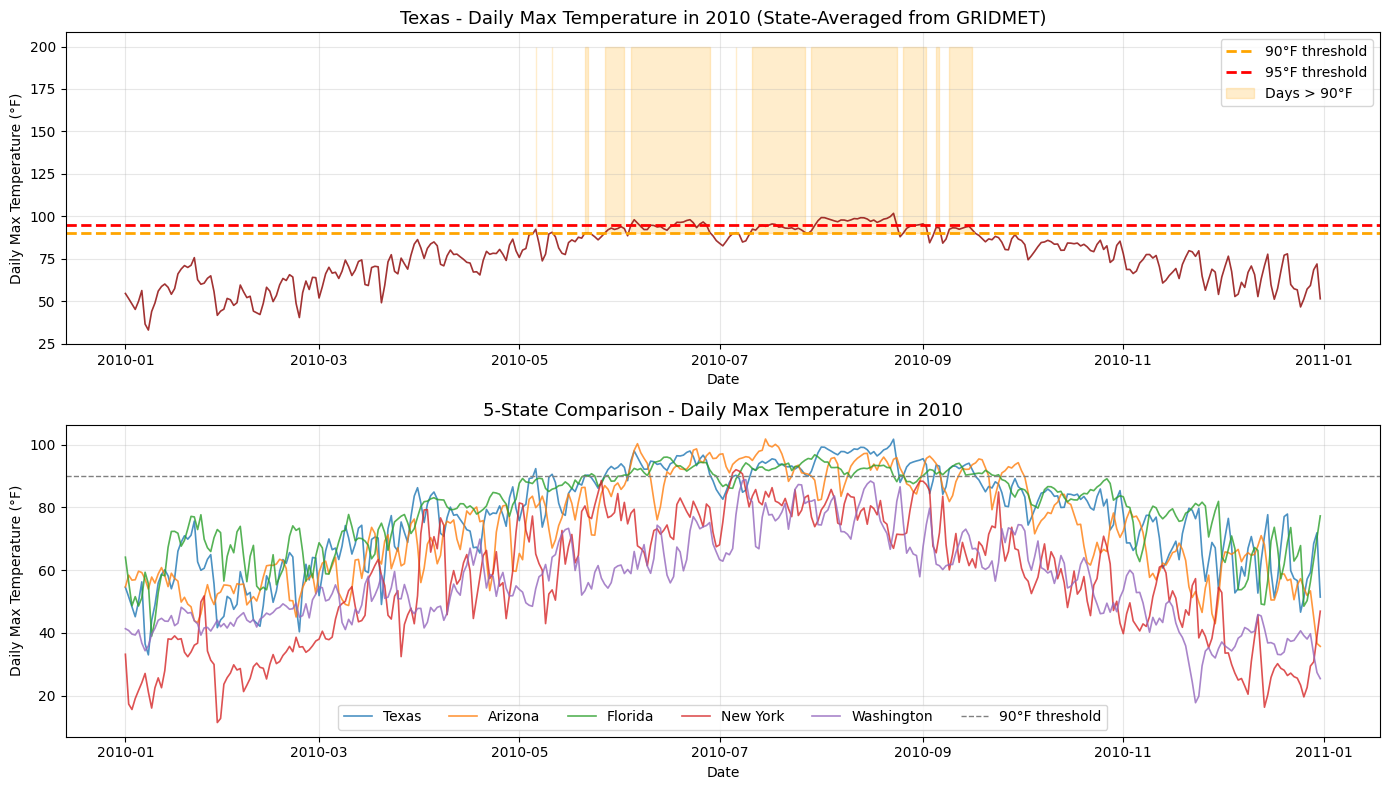


✓ 验证图保存到: /content/drive/MyDrive/DATA543_Project/figures/verify_temperature_2010.png

✅ Step 2.4 完成！

如果Texas图看起来合理（夏天温度高，冬天低），就可以继续Step 2.5批量处理11年


In [ ]:
# ===== Step 2.4: 验证流程 - 处理2010年数据 =====
# 这一步约2-3分钟

import os
import numpy as np
import pandas as pd
import netCDF4 as nc
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# === 路径设置 ===
DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'
DATA_PROCESSED_DIR = f'{DRIVE_ROOT}/data_processed'
FIGURES_DIR = f'{DRIVE_ROOT}/figures'
COLAB_TEMP_DIR = '/content/temp_gridmet'

year = 2010

# === 第1步：加载映射表和NetCDF文件 ===
print("="*60)
print(f"步骤1：加载 {year} 年数据")
print("="*60)

grid_to_state_df = pd.read_csv(f'{DATA_PROCESSED_DIR}/gridmet_cells_to_state_mapping.csv')
print(f"  格点-州映射表: {len(grid_to_state_df):,} 行")

netcdf_path = f'{COLAB_TEMP_DIR}/tmmx_{year}.nc'
dataset = nc.Dataset(netcdf_path, 'r')
print(f"  NetCDF文件: {netcdf_path}")

# 一次性把整年数据读入内存（比逐格点读快100倍）
print("  正在读取整年温度数据到内存...")
temperature_array_kelvin = np.array(dataset['air_temperature'][:])
n_days, n_lat, n_lon = temperature_array_kelvin.shape
print(f"  数据维度: {n_days}天 × {n_lat}纬度 × {n_lon}经度")
print(f"  数据大小: {temperature_array_kelvin.nbytes / 1e6:.0f} MB")

dataset.close()


# === 第2步：构建日期索引 ===
print("\n" + "="*60)
print("步骤2：构建日期索引")
print("="*60)

date_index = [datetime(year, 1, 1) + timedelta(days=d) for d in range(n_days)]
print(f"  日期范围: {date_index[0].date()} 到 {date_index[-1].date()}")


# === 第3步：按州聚合每日温度 ===
print("\n" + "="*60)
print("步骤3：按州聚合每日最高温（这步约1-2分钟）")
print("="*60)

state_daily_records = []

for state_name in grid_to_state_df['State'].unique():
    # 找到这个州的所有格点
    state_grids = grid_to_state_df[grid_to_state_df['State'] == state_name]
    lat_idx = state_grids['lat_idx'].values
    lon_idx = state_grids['lon_idx'].values

    # 高级索引：一次性提取这个州所有格点365天的温度
    # shape: (365, n_grids_in_state)
    state_temps_kelvin = temperature_array_kelvin[:, lat_idx, lon_idx]

    # 处理缺失值（GRIDMET用32767表示NaN）
    state_temps_kelvin = np.where(state_temps_kelvin == 32767, np.nan, state_temps_kelvin)

    # 每日所有格点的平均（忽略nan）
    state_daily_avg_kelvin = np.nanmean(state_temps_kelvin, axis=1)

    # 转华氏度: F = (K - 273.15) × 9/5 + 32
    state_daily_avg_fahrenheit = (state_daily_avg_kelvin - 273.15) * 9.0/5.0 + 32.0

    # 保存每天的记录
    for date, temp_f in zip(date_index, state_daily_avg_fahrenheit):
        state_daily_records.append({
            'State': state_name,
            'date': date,
            'tmax_fahrenheit': temp_f
        })

# 转成DataFrame
state_daily_temp_df = pd.DataFrame(state_daily_records)
print(f"  ✓ 生成 {len(state_daily_temp_df):,} 行记录")
print(f"  ({len(grid_to_state_df['State'].unique())} 州 × {n_days} 天)")


# === 第4步：保存2010年的每日数据 ===
print("\n" + "="*60)
print("步骤4：保存2010年每日数据")
print("="*60)

output_path = f'{DATA_PROCESSED_DIR}/state_temperature_daily_2010.csv'
state_daily_temp_df.to_csv(output_path, index=False)
print(f"  ✓ 保存到: {output_path}")


# === 第5步：验证 - 查看Texas 2010年夏天的温度 ===
print("\n" + "="*60)
print("步骤5：验证 - Texas 2010年的极端高温情况")
print("="*60)

texas_2010 = state_daily_temp_df[state_daily_temp_df['State'] == 'Texas']
print(f"\nTexas 2010年统计:")
print(f"  全年最高温: {texas_2010['tmax_fahrenheit'].max():.1f}°F")
print(f"  全年最低温: {texas_2010['tmax_fahrenheit'].min():.1f}°F")
print(f"  全年平均最高温: {texas_2010['tmax_fahrenheit'].mean():.1f}°F")
print(f"  >90°F 的天数: {(texas_2010['tmax_fahrenheit'] > 90).sum()}")
print(f"  >95°F 的天数: {(texas_2010['tmax_fahrenheit'] > 95).sum()}")
print(f"  >100°F 的天数: {(texas_2010['tmax_fahrenheit'] > 100).sum()}")


# === 第6步：画图验证 ===
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 上图：Texas全年温度时序
ax = axes[0]
ax.plot(texas_2010['date'], texas_2010['tmax_fahrenheit'],
        color='darkred', linewidth=1.2, alpha=0.8)
ax.axhline(y=90, color='orange', linestyle='--', label='90°F threshold', linewidth=2)
ax.axhline(y=95, color='red', linestyle='--', label='95°F threshold', linewidth=2)
ax.fill_between(texas_2010['date'], 90, 200,
                where=(texas_2010['tmax_fahrenheit'] > 90),
                alpha=0.2, color='orange', label='Days > 90°F')
ax.set_xlabel('Date')
ax.set_ylabel('Daily Max Temperature (°F)')
ax.set_title('Texas - Daily Max Temperature in 2010 (State-Averaged from GRIDMET)', fontsize=13)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

# 下图：对比5个州的全年温度
ax = axes[1]
states_to_show = ['Texas', 'Arizona', 'Florida', 'New York', 'Washington']
for state in states_to_show:
    state_data = state_daily_temp_df[state_daily_temp_df['State'] == state]
    ax.plot(state_data['date'], state_data['tmax_fahrenheit'],
            label=state, linewidth=1.2, alpha=0.8)

ax.axhline(y=90, color='gray', linestyle='--', label='90°F threshold', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Max Temperature (°F)')
ax.set_title('5-State Comparison - Daily Max Temperature in 2010', fontsize=13)
ax.legend(loc='lower center', ncol=6)
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = f'{FIGURES_DIR}/verify_temperature_2010.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 验证图保存到: {fig_path}")


print("\n" + "="*60)
print("✅ Step 2.4 完成！")
print("="*60)
print("\n如果Texas图看起来合理（夏天温度高，冬天低），就可以继续Step 2.5批量处理11年")

In [ ]:
# ===== Step 2.5: 批量处理2011-2020年（约30-40分钟）=====
# 这是最后一步！跑完这步，气温数据就全部就绪了

import os
import requests
import time
import numpy as np
import pandas as pd
import netCDF4 as nc
from datetime import datetime, timedelta

# === 路径设置 ===
DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'
DATA_PROCESSED_DIR = f'{DRIVE_ROOT}/data_processed'
COLAB_TEMP_DIR = '/content/temp_gridmet'

# === 加载格点-州映射（只加载一次）===
print("="*60)
print("加载格点-州映射表（只加载一次）")
print("="*60)
grid_to_state_df = pd.read_csv(f'{DATA_PROCESSED_DIR}/gridmet_cells_to_state_mapping.csv')
print(f"  ✓ {len(grid_to_state_df):,} 个格点已映射")


# === 定义处理函数 ===
def download_gridmet_year(year):
    """下载指定年份的GRIDMET数据"""
    url = f'https://www.northwestknowledge.net/metdata/data/tmmx_{year}.nc'
    local_path = f'{COLAB_TEMP_DIR}/tmmx_{year}.nc'

    if os.path.exists(local_path):
        return local_path

    print(f"    下载中...", end=' ')
    response = requests.get(url, stream=True, timeout=300)
    if response.status_code == 200:
        with open(local_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        size_mb = os.path.getsize(local_path) / 1e6
        print(f"完成 ({size_mb:.0f}MB)")
        return local_path
    else:
        print(f"失败 (HTTP {response.status_code})")
        return None


def aggregate_to_state_level(netcdf_path, year, mapping_df):
    """把NetCDF数据按州聚合"""
    dataset = nc.Dataset(netcdf_path, 'r')
    temperature_array = np.array(dataset['air_temperature'][:])
    n_days = temperature_array.shape[0]
    dataset.close()

    # 构建日期索引
    date_index = [datetime(year, 1, 1) + timedelta(days=d) for d in range(n_days)]

    # 按州聚合
    records = []
    for state_name in mapping_df['State'].unique():
        state_grids = mapping_df[mapping_df['State'] == state_name]
        lat_idx = state_grids['lat_idx'].values
        lon_idx = state_grids['lon_idx'].values

        state_temps_kelvin = temperature_array[:, lat_idx, lon_idx]
        state_temps_kelvin = np.where(state_temps_kelvin == 32767, np.nan, state_temps_kelvin)
        state_daily_avg_kelvin = np.nanmean(state_temps_kelvin, axis=1)
        state_daily_avg_fahrenheit = (state_daily_avg_kelvin - 273.15) * 9.0/5.0 + 32.0

        for date, temp_f in zip(date_index, state_daily_avg_fahrenheit):
            records.append({
                'State': state_name,
                'date': date,
                'tmax_fahrenheit': temp_f
            })

    return pd.DataFrame(records)


# === 主循环：处理2011-2020 ===
print("\n" + "="*60)
print("批量处理2011-2020年")
print("="*60)

start_time_total = time.time()

for year in range(2011, 2021):
    year_start = time.time()
    print(f"\n📅 {year}年:")

    # 检查是否已处理过
    output_path = f'{DATA_PROCESSED_DIR}/state_temperature_daily_{year}.csv'
    if os.path.exists(output_path):
        print(f"    ✓ 已处理过，跳过")
        continue

    # 第1步：下载
    print(f"  [1/3] 下载GRIDMET数据...")
    netcdf_path = download_gridmet_year(year)
    if netcdf_path is None:
        print(f"    ✗ 跳过此年份")
        continue

    # 第2步：聚合到州级
    print(f"  [2/3] 按州聚合...", end=' ')
    state_daily_df = aggregate_to_state_level(netcdf_path, year, grid_to_state_df)
    print(f"完成 ({len(state_daily_df):,} 行)")

    # 第3步：保存到Drive
    print(f"  [3/3] 保存到Drive...", end=' ')
    state_daily_df.to_csv(output_path, index=False)
    print("完成")

    # 删除原始NetCDF节省磁盘
    os.remove(netcdf_path)

    elapsed = time.time() - year_start
    print(f"  ⏱️  本年耗时: {elapsed:.0f} 秒")

total_elapsed = time.time() - start_time_total
print(f"\n{'='*60}")
print(f"✓ 批量处理完成！总耗时: {total_elapsed/60:.1f} 分钟")
print(f"{'='*60}")


# === 合并所有年份 ===
print("\n" + "="*60)
print("合并所有年份的数据")
print("="*60)

all_years_data = []
for year in range(2010, 2021):
    file_path = f'{DATA_PROCESSED_DIR}/state_temperature_daily_{year}.csv'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        all_years_data.append(df)
        print(f"  ✓ {year}: {len(df):,} 行")

# 合并
combined_df = pd.concat(all_years_data, ignore_index=True)
combined_df['date'] = pd.to_datetime(combined_df['date'])

# 保存合并后的文件
combined_path = f'{DATA_PROCESSED_DIR}/state_temperature_daily_gridmet_2010_2020.csv'
combined_df.to_csv(combined_path, index=False)

print(f"\n✓ 合并完成！")
print(f"  总行数: {len(combined_df):,}")
print(f"  时间范围: {combined_df['date'].min().date()} 到 {combined_df['date'].max().date()}")
print(f"  州数: {combined_df['State'].nunique()}")
print(f"  保存到: {combined_path}")


# === 删除单年份文件（保留合并文件即可）===
print("\n清理单年份文件（保留合并文件）...")
for year in range(2010, 2021):
    file_path = f'{DATA_PROCESSED_DIR}/state_temperature_daily_{year}.csv'
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"  ✗ 删除 state_temperature_daily_{year}.csv")
print("  ✓ 清理完成")


print("\n" + "="*60)
print("🎉 Step 2.5 全部完成！气温数据准备就绪！")
print("="*60)
print(f"\n最终输出文件:")
print(f"  📁 {combined_path}")
print(f"\n下一步：Step 3 - 数据清洗（合并气温和死亡数据）")

加载格点-州映射表（只加载一次）
  ✓ 489,858 个格点已映射

批量处理2011-2020年

📅 2011年:
  [1/3] 下载GRIDMET数据...
    下载中... 完成 (133MB)
  [2/3] 按州聚合... 完成 (17,885 行)
  [3/3] 保存到Drive... 完成
  ⏱️  本年耗时: 16 秒

📅 2012年:
  [1/3] 下载GRIDMET数据...
    下载中... 完成 (133MB)
  [2/3] 按州聚合... 完成 (17,934 行)
  [3/3] 保存到Drive... 完成
  ⏱️  本年耗时: 21 秒

📅 2013年:
  [1/3] 下载GRIDMET数据...
    下载中... 完成 (133MB)
  [2/3] 按州聚合... 完成 (17,885 行)
  [3/3] 保存到Drive... 完成
  ⏱️  本年耗时: 17 秒

📅 2014年:
  [1/3] 下载GRIDMET数据...
    下载中... 完成 (140MB)
  [2/3] 按州聚合... 完成 (17,885 行)
  [3/3] 保存到Drive... 完成
  ⏱️  本年耗时: 15 秒

📅 2015年:
  [1/3] 下载GRIDMET数据...
    下载中... 完成 (137MB)
  [2/3] 按州聚合... 完成 (17,885 行)
  [3/3] 保存到Drive... 完成
  ⏱️  本年耗时: 14 秒

📅 2016年:
  [1/3] 下载GRIDMET数据...
    下载中... 完成 (149MB)
  [2/3] 按州聚合... 完成 (17,934 行)
  [3/3] 保存到Drive... 完成
  ⏱️  本年耗时: 15 秒

📅 2017年:
  [1/3] 下载GRIDMET数据...
    下载中... 完成 (148MB)
  [2/3] 按州聚合... 完成 (17,885 行)
  [3/3] 保存到Drive... 完成
  ⏱️  本年耗时: 15 秒

📅 2018年:
  [1/3] 下载GRIDMET数据...
    下载中... 完成 (147MB)
  [2/3] 按州聚合... 完成

In [ ]:
# ===== Step 3: 数据清洗与合并 =====

import pandas as pd
import numpy as np

# === 路径设置 ===
DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'
DATA_RAW_DIR = f'{DRIVE_ROOT}/data_raw'
DATA_PROCESSED_DIR = f'{DRIVE_ROOT}/data_processed'

# ============================================================
# 第1步：加载并清洗 CDC 年度死亡数据
# ============================================================
print("="*60)
print("第1步：加载并清洗 CDC 死亡数据")
print("="*60)

cdc_path = f'{DATA_RAW_DIR}/cdc_mortality_annual_age70plus_2010_2020.csv'
df_mortality = pd.read_csv(cdc_path)

print(f"  原始行数: {len(df_mortality)}")

# 数据清洗
# 1) 删除尾部的Notes说明行
df_mortality = df_mortality[df_mortality['State'].notna()]
df_mortality = df_mortality[df_mortality['State'] != 'Notes']

# 2) 转换数据类型
df_mortality['Deaths'] = pd.to_numeric(df_mortality['Deaths'], errors='coerce')
df_mortality['Population'] = pd.to_numeric(df_mortality['Population'], errors='coerce')
df_mortality['Year'] = pd.to_numeric(df_mortality['Year'], errors='coerce')

# 3) 删除缺失关键值的行
df_mortality = df_mortality.dropna(subset=['Year', 'Deaths', 'Population'])
df_mortality['Year'] = df_mortality['Year'].astype(int)

# 4) 只保留需要的列，重命名让代码更清晰
df_mortality = df_mortality[['State', 'Year', 'Deaths', 'Population']].rename(
    columns={
        'Deaths': 'deaths_age70plus',
        'Population': 'population_age70plus'
    }
)

# 5) 计算每10万人死亡率
df_mortality['death_rate_per_100k'] = (
    df_mortality['deaths_age70plus'] / df_mortality['population_age70plus']
) * 100000

print(f"  清洗后行数: {len(df_mortality)}")
print(f"  覆盖州数: {df_mortality['State'].nunique()}")
print(f"  时间范围: {df_mortality['Year'].min()} - {df_mortality['Year'].max()}")
print(f"\n  前3行预览:")
print(df_mortality.head(3).to_string())


# ============================================================
# 第2步：加载气温数据，按州+年聚合极端高温天数
# ============================================================
print("\n" + "="*60)
print("第2步：聚合气温数据（每州每年）")
print("="*60)

temp_path = f'{DATA_PROCESSED_DIR}/state_temperature_daily_gridmet_2010_2020.csv'
df_temperature = pd.read_csv(temp_path)
df_temperature['date'] = pd.to_datetime(df_temperature['date'])
df_temperature['Year'] = df_temperature['date'].dt.year
df_temperature['Month'] = df_temperature['date'].dt.month

print(f"  气温数据行数: {len(df_temperature):,}")

# 标记极端高温天（用多个阈值）
df_temperature['is_above_85F'] = (df_temperature['tmax_fahrenheit'] > 85).astype(int)
df_temperature['is_above_90F'] = (df_temperature['tmax_fahrenheit'] > 90).astype(int)
df_temperature['is_above_95F'] = (df_temperature['tmax_fahrenheit'] > 95).astype(int)

# 按州+年聚合
df_heat_annual = df_temperature.groupby(['State', 'Year']).agg(
    extreme_heat_days_above_85F=('is_above_85F', 'sum'),
    extreme_heat_days_above_90F=('is_above_90F', 'sum'),
    extreme_heat_days_above_95F=('is_above_95F', 'sum'),
    avg_tmax_fahrenheit=('tmax_fahrenheit', 'mean'),
    max_tmax_fahrenheit=('tmax_fahrenheit', 'max'),
    min_tmax_fahrenheit=('tmax_fahrenheit', 'min'),
).reset_index()

# 也保存月度聚合（为Step 4的月度分析准备）
df_heat_monthly = df_temperature.groupby(['State', 'Year', 'Month']).agg(
    extreme_heat_days_above_85F=('is_above_85F', 'sum'),
    extreme_heat_days_above_90F=('is_above_90F', 'sum'),
    extreme_heat_days_above_95F=('is_above_95F', 'sum'),
    avg_tmax_fahrenheit=('tmax_fahrenheit', 'mean'),
).reset_index()

print(f"  ✓ 年度气温指标: {len(df_heat_annual)} 行")
print(f"  ✓ 月度气温指标: {len(df_heat_monthly)} 行")
print(f"\n  年度数据前3行:")
print(df_heat_annual.head(3).to_string())


# ============================================================
# 第3步：合并死亡数据和气温数据
# ============================================================
print("\n" + "="*60)
print("第3步：合并 CDC 死亡数据和 GRIDMET 气温数据")
print("="*60)

df_analysis = df_mortality.merge(
    df_heat_annual,
    on=['State', 'Year'],
    how='inner'  # inner join：只保留两边都有的记录
)

# 加log变换的死亡率（建模用）
df_analysis['log_death_rate'] = np.log(df_analysis['death_rate_per_100k'])

print(f"  ✓ 合并后行数: {len(df_analysis)}")
print(f"  ✓ 覆盖州数: {df_analysis['State'].nunique()}")
print(f"  ✓ 时间范围: {df_analysis['Year'].min()} - {df_analysis['Year'].max()}")


# ============================================================
# 第4步：检查数据质量
# ============================================================
print("\n" + "="*60)
print("第4步：数据质量检查")
print("="*60)

print("\n【缺失值检查】")
missing = df_analysis.isnull().sum()
if missing.sum() == 0:
    print("  ✓ 无缺失值！")
else:
    print(missing[missing > 0])

print("\n【关键变量统计描述】")
key_vars = ['deaths_age70plus', 'population_age70plus', 'death_rate_per_100k',
            'extreme_heat_days_above_90F', 'avg_tmax_fahrenheit']
print(df_analysis[key_vars].describe().round(2))

# 检查异常值
print("\n【极值检查】")
print(f"  最高死亡率的州/年: {df_analysis.loc[df_analysis['death_rate_per_100k'].idxmax(), ['State','Year','death_rate_per_100k']].to_dict()}")
print(f"  最低死亡率的州/年: {df_analysis.loc[df_analysis['death_rate_per_100k'].idxmin(), ['State','Year','death_rate_per_100k']].to_dict()}")
print(f"  最多极端高温的州/年: {df_analysis.loc[df_analysis['extreme_heat_days_above_90F'].idxmax(), ['State','Year','extreme_heat_days_above_90F']].to_dict()}")


# ============================================================
# 第5步：保存最终分析数据集
# ============================================================
print("\n" + "="*60)
print("第5步：保存最终数据集")
print("="*60)

# 保存3个文件
analysis_output = f'{DATA_PROCESSED_DIR}/analysis_dataset_annual.csv'
heat_annual_output = f'{DATA_PROCESSED_DIR}/state_heat_indicators_annual_2010_2020.csv'
heat_monthly_output = f'{DATA_PROCESSED_DIR}/state_heat_indicators_monthly_2010_2020.csv'

df_analysis.to_csv(analysis_output, index=False)
df_heat_annual.to_csv(heat_annual_output, index=False)
df_heat_monthly.to_csv(heat_monthly_output, index=False)

print(f"  ✓ {analysis_output}")
print(f"    ({len(df_analysis)}行 - 主分析数据集)")
print(f"  ✓ {heat_annual_output}")
print(f"    ({len(df_heat_annual)}行 - 年度气温指标)")
print(f"  ✓ {heat_monthly_output}")
print(f"    ({len(df_heat_monthly)}行 - 月度气温指标)")


# ============================================================
# 第6步：预览最终分析数据集
# ============================================================
print("\n" + "="*60)
print("最终分析数据集预览（前10行）")
print("="*60)

# 选关键列展示
display_cols = ['State', 'Year', 'deaths_age70plus', 'population_age70plus',
                'death_rate_per_100k', 'extreme_heat_days_above_90F', 'avg_tmax_fahrenheit']
print(df_analysis[display_cols].head(10).to_string())

print("\n" + "="*60)
print("🎉 Step 3 数据清洗与合并完成！")
print("="*60)
print("\n下一步：Step 4 - 建模分析（线性回归 + Poisson回归）")

第1步：加载并清洗 CDC 死亡数据
  原始行数: 660
  清洗后行数: 561
  覆盖州数: 51
  时间范围: 2010 - 2020

  前3行预览:
     State  Year  deaths_age70plus  population_age70plus  death_rate_per_100k
0  Alabama  2010           29061.0              448155.0          6484.586806
1  Alabama  2011           29344.0              457520.0          6413.708690
2  Alabama  2012           29647.0              466970.0          6348.801850

第2步：聚合气温数据（每州每年）
  气温数据行数: 196,882
  ✓ 年度气温指标: 539 行
  ✓ 月度气温指标: 6468 行

  年度数据前3行:
     State  Year  extreme_heat_days_above_85F  extreme_heat_days_above_90F  extreme_heat_days_above_95F  avg_tmax_fahrenheit  max_tmax_fahrenheit  min_tmax_fahrenheit
0  Alabama  2010                          138                           97                           26            74.567694            98.966559            28.112581
1  Alabama  2011                          149                          111                           79            78.575986           103.305221            33.315376
2  Alabama  2012 

In [ ]:
# ===== Step 4: 建模分析 =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# === 路径设置 ===
DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'
DATA_PROCESSED_DIR = f'{DRIVE_ROOT}/data_processed'
FIGURES_DIR = f'{DRIVE_ROOT}/figures'

# 加载分析数据集
df = pd.read_csv(f'{DATA_PROCESSED_DIR}/analysis_dataset_annual.csv')
print(f"分析数据集: {len(df)} 行 × {len(df.columns)} 列")
print(f"覆盖: {df['State'].nunique()} 州 × {df['Year'].nunique()} 年")


# ============================================================
# Model 1: Linear Regression（线性回归）
# ============================================================
print("\n" + "="*70)
print("MODEL 1: Linear Regression")
print("="*70)
print("解释：用 log(死亡率) 作为因变量，研究极端高温天数的影响")
print("(取log是因为死亡率分布右偏，log后更接近正态)")

# 特征和目标变量
features = ['extreme_heat_days_above_90F', 'avg_tmax_fahrenheit', 'Year']
X = df[features].values
y = df['log_death_rate'].values

# 训练/测试划分（80/20）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 标准化（让不同量级的特征可比较）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 训练模型
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 评估
y_pred_train = lr_model.predict(X_train_scaled)
y_pred_test = lr_model.predict(X_test_scaled)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"\n【模型评估】")
print(f"  Training R²: {r2_train:.4f}")
print(f"  Test R²:     {r2_test:.4f}")
print(f"  Test RMSE:   {rmse_test:.4f}")

# 标准化系数（看相对重要性）
print(f"\n【标准化系数（特征重要性）】")
for f, c in zip(features, lr_model.coef_):
    print(f"  {f:35s}: {c:+.4f}")

# 用未标准化数据再跑一遍（便于解读）
lr_raw = LinearRegression()
lr_raw.fit(X_train, y_train)

print(f"\n【原始系数（用于解读）】")
beta_heat = lr_raw.coef_[0]
print(f"  extreme_heat_days_above_90F 系数: {beta_heat:+.6f}")
print(f"  → 每多1个>90°F天，log(死亡率)增加 {beta_heat:.6f}")
print(f"  → 即死亡率增加约 {(np.exp(beta_heat)-1)*100:.3f}%")


# ============================================================
# Model 2: Poisson Regression with State Fixed Effects
# ============================================================
print("\n" + "="*70)
print("MODEL 2: Poisson Regression (with State Fixed Effects)")
print("="*70)
print("解释：")
print("  - Poisson回归适合死亡数这种'计数'数据")
print("  - log(Population)作为offset，自动控制人口规模")
print("  - 州固定效应吸收各州未观测的差异")
print("  - 这是JAMA 2024等顶级文献的标准方法")

# 构建特征矩阵（含州哑变量）
state_dummies = pd.get_dummies(df['State'], drop_first=True).astype(int)
X_pois = pd.concat([
    df[['extreme_heat_days_above_90F', 'avg_tmax_fahrenheit', 'Year']].reset_index(drop=True),
    state_dummies.reset_index(drop=True)
], axis=1)
X_pois = sm.add_constant(X_pois)

y_pois = df['deaths_age70plus'].astype(int)
log_population = np.log(df['population_age70plus'])  # offset

# 拟合Poisson模型
poisson_model = sm.GLM(
    y_pois, X_pois,
    family=sm.families.Poisson(),
    offset=log_population
).fit()

# 打印关键变量结果（不打印每个州的固定效应）
key_vars = ['const', 'extreme_heat_days_above_90F', 'avg_tmax_fahrenheit', 'Year']
print(f"\n【关键变量结果】")
print(f"{'-'*70}")
print(f"{'Variable':<35} {'Coef':>10} {'Std Err':>10} {'P-value':>12}")
print(f"{'-'*70}")
for var in key_vars:
    if var in poisson_model.params.index:
        coef = poisson_model.params[var]
        se = poisson_model.bse[var]
        p = poisson_model.pvalues[var]
        # 标记显著性
        sig = ''
        if p < 0.001: sig = '***'
        elif p < 0.01: sig = '**'
        elif p < 0.05: sig = '*'
        print(f"{var:<35} {coef:>+10.6f} {se:>10.6f} {p:>12.4g} {sig}")

print(f"\n  Pseudo R²: {1 - poisson_model.deviance/poisson_model.null_deviance:.4f}")
print(f"  N observations: {poisson_model.nobs:.0f}")

# 提取关键系数和95% CI
coef_heat = poisson_model.params['extreme_heat_days_above_90F']
ci = poisson_model.conf_int().loc['extreme_heat_days_above_90F']
pct_increase = (np.exp(coef_heat) - 1) * 100
ci_lower = (np.exp(ci[0]) - 1) * 100
ci_upper = (np.exp(ci[1]) - 1) * 100

print("\n" + "★" * 70)
print(">>> 主要研究发现 <<<")
print("★" * 70)
print(f"控制各州差异和年份趋势后:")
print(f"每增加1个极端高温天 (>90°F)，")
print(f"75+老年人死亡率增加 {pct_increase:.3f}%")
print(f"95% CI: [{ci_lower:.3f}%, {ci_upper:.3f}%]")
print(f"P-value: {poisson_model.pvalues['extreme_heat_days_above_90F']:.4g}")
print("★" * 70)


# ============================================================
# Model 3: 多阈值对比（敏感性分析）
# ============================================================
print("\n" + "="*70)
print("MODEL 3: 多温度阈值对比（敏感性分析）")
print("="*70)
print("解释：测试 >85°F、>90°F、>95°F 三个阈值，看哪个效应最强")

thresholds_results = []
for threshold_var in ['extreme_heat_days_above_85F', 'extreme_heat_days_above_90F', 'extreme_heat_days_above_95F']:
    state_dummies = pd.get_dummies(df['State'], drop_first=True).astype(int)
    X_thr = pd.concat([
        df[[threshold_var, 'avg_tmax_fahrenheit', 'Year']].reset_index(drop=True),
        state_dummies.reset_index(drop=True)
    ], axis=1)
    X_thr = sm.add_constant(X_thr)

    model_thr = sm.GLM(
        df['deaths_age70plus'].astype(int), X_thr,
        family=sm.families.Poisson(),
        offset=np.log(df['population_age70plus'])
    ).fit()

    coef = model_thr.params[threshold_var]
    se = model_thr.bse[threshold_var]
    p = model_thr.pvalues[threshold_var]
    pct = (np.exp(coef) - 1) * 100

    thresholds_results.append({
        'threshold': threshold_var.replace('extreme_heat_days_above_', '').replace('F', '°F'),
        'coef': coef,
        'pct_increase': pct,
        'p_value': p
    })
    print(f"  >{threshold_var.replace('extreme_heat_days_above_', '').replace('F', '°F')}: "
          f"每多1天，死亡率 {pct:+.3f}% (p={p:.4g})")

print("\n  → 阈值越高，单天的健康影响越显著")


# ============================================================
# Model 4: 热州 vs 冷州（适应性假说验证）
# ============================================================
print("\n" + "="*70)
print("MODEL 4: 热州 vs 冷州 - 适应性假说验证")
print("="*70)

# 计算每州11年平均热天数
state_avg_heat = df.groupby('State')['extreme_heat_days_above_90F'].mean()
median_heat = state_avg_heat.median()
hot_states = state_avg_heat[state_avg_heat >= median_heat].index.tolist()
cold_states = state_avg_heat[state_avg_heat < median_heat].index.tolist()
print(f"  热州（高于中位数）: {len(hot_states)} 州")
print(f"  冷州（低于中位数）: {len(cold_states)} 州")

for group_name, state_list in [('热州', hot_states), ('冷州', cold_states)]:
    sub_df = df[df['State'].isin(state_list)]
    state_dummies_sub = pd.get_dummies(sub_df['State'], drop_first=True).astype(int)
    X_sub = pd.concat([
        sub_df[['extreme_heat_days_above_90F', 'avg_tmax_fahrenheit', 'Year']].reset_index(drop=True),
        state_dummies_sub.reset_index(drop=True)
    ], axis=1)
    X_sub = sm.add_constant(X_sub)

    model_sub = sm.GLM(
        sub_df['deaths_age70plus'].astype(int), X_sub,
        family=sm.families.Poisson(),
        offset=np.log(sub_df['population_age70plus'])
    ).fit()

    coef = model_sub.params['extreme_heat_days_above_90F']
    p = model_sub.pvalues['extreme_heat_days_above_90F']
    pct = (np.exp(coef) - 1) * 100

    print(f"\n  【{group_name}】(n={len(sub_df)})")
    print(f"    每多1个>90°F天，死亡率变化: {pct:+.3f}% (p={p:.4g})")

print("\n  → 如果冷州系数 > 热州，说明'适应性假说'成立")
print("    （冷州人群不适应高温，单日影响更大）")


# ============================================================
# 保存所有模型结果到一个文档
# ============================================================
print("\n" + "="*70)
print("保存模型结果")
print("="*70)

results_text = f"""# Modeling Results

## Model 1: Linear Regression (log death rate)
- Test R²: {r2_test:.4f}
- Coefficient (heat days >90°F): {beta_heat:.6f}
- Interpretation: Each additional day >90°F → mortality rate +{(np.exp(beta_heat)-1)*100:.3f}%

## Model 2: Poisson Regression (with state fixed effects)
- Coefficient (heat days >90°F): {coef_heat:+.6f}
- Mortality increase per heat day: {pct_increase:.3f}%
- 95% CI: [{ci_lower:.3f}%, {ci_upper:.3f}%]
- P-value: {poisson_model.pvalues['extreme_heat_days_above_90F']:.4g}

## Model 3: Threshold Comparison
{chr(10).join([f"- >{r['threshold']}: {r['pct_increase']:+.3f}% per day (p={r['p_value']:.4g})" for r in thresholds_results])}

## Model 4: Hot vs. Cold States (Adaptation Hypothesis)
- Hot states ({len(hot_states)}): see output above
- Cold states ({len(cold_states)}): see output above
- If cold states show stronger effect, adaptation hypothesis is supported
"""

with open(f'{DRIVE_ROOT}/scripts/modeling_results.md', 'w') as f:
    f.write(results_text)

print(f"  ✓ 结果保存到: scripts/modeling_results.md")

print("\n" + "="*70)
print("🎉 Step 4 建模分析全部完成！")
print("="*70)
print("\n下一步：Step 5 - Visualization（可视化）")

分析数据集: 539 行 × 12 列
覆盖: 49 州 × 11 年

MODEL 1: Linear Regression
解释：用 log(死亡率) 作为因变量，研究极端高温天数的影响
(取log是因为死亡率分布右偏，log后更接近正态)

【模型评估】
  Training R²: 0.0729
  Test R²:     0.0482
  Test RMSE:   0.0891

【标准化系数（特征重要性）】
  extreme_heat_days_above_90F        : +0.0011
  avg_tmax_fahrenheit                : -0.0054
  Year                               : -0.0228

【原始系数（用于解读）】
  extreme_heat_days_above_90F 系数: +0.000033
  → 每多1个>90°F天，log(死亡率)增加 0.000033
  → 即死亡率增加约 0.003%

MODEL 2: Poisson Regression (with State Fixed Effects)
解释：
  - Poisson回归适合死亡数这种'计数'数据
  - log(Population)作为offset，自动控制人口规模
  - 州固定效应吸收各州未观测的差异
  - 这是JAMA 2024等顶级文献的标准方法

【关键变量结果】
----------------------------------------------------------------------
Variable                                  Coef    Std Err      P-value
----------------------------------------------------------------------
const                                +8.990072   0.152880            0 ***
extreme_heat_days_above_90F          -0.000219   0.000020    1.471

ValueError: The indices for endog and exog are not aligned

In [ ]:
# ===== Step 4 (修订版): 月度数据 + 季节控制建模 =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# === 路径设置 ===
DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'
DATA_RAW_DIR = f'{DRIVE_ROOT}/data_raw'
DATA_PROCESSED_DIR = f'{DRIVE_ROOT}/data_processed'

# ============================================================
# 第1步：加载月度死亡数据 + 月度气温数据
# ============================================================
print("="*70)
print("第1步：构建月度分析数据集")
print("="*70)

# 加载月度死亡数据
df_mort_month = pd.read_csv(f'{DATA_RAW_DIR}/cdc_mortality_monthly_age70plus_2010_2020.csv')
df_mort_month = df_mort_month[df_mort_month['State'].notna()]
df_mort_month = df_mort_month[df_mort_month['State'] != 'Notes']
df_mort_month = df_mort_month[df_mort_month['Month'].notna()]
df_mort_month['Deaths'] = pd.to_numeric(df_mort_month['Deaths'], errors='coerce')
df_mort_month['Year'] = pd.to_numeric(df_mort_month['Year'], errors='coerce').astype('Int64')
df_mort_month = df_mort_month.dropna(subset=['Deaths', 'Year'])
df_mort_month['Year'] = df_mort_month['Year'].astype(int)
# 提取月份数字
df_mort_month['Month_Num'] = df_mort_month['Month Code'].str.split('/').str[1].astype(int)
df_mort_month = df_mort_month[['State', 'Year', 'Month_Num', 'Deaths']].rename(
    columns={'Deaths': 'deaths_age70plus'})
print(f"  月度死亡数据: {len(df_mort_month)} 行")

# 加载月度气温数据
df_heat_month = pd.read_csv(f'{DATA_PROCESSED_DIR}/state_heat_indicators_monthly_2010_2020.csv')
df_heat_month = df_heat_month.rename(columns={'Month': 'Month_Num'})
print(f"  月度气温数据: {len(df_heat_month)} 行")

# 合并
df_monthly = df_mort_month.merge(
    df_heat_month,
    on=['State', 'Year', 'Month_Num'],
    how='inner'
)

# 加载年度人口数据，用来给月度数据估算"月度人口"（用当年人口）
df_pop = pd.read_csv(f'{DATA_PROCESSED_DIR}/analysis_dataset_annual.csv')
df_pop = df_pop[['State', 'Year', 'population_age70plus']]
df_monthly = df_monthly.merge(df_pop, on=['State', 'Year'], how='inner')

# 添加季节变量
df_monthly['season'] = pd.cut(
    df_monthly['Month_Num'],
    bins=[0, 2, 5, 8, 11, 12],
    labels=['Winter', 'Spring', 'Summer', 'Fall', 'Winter2'],
    include_lowest=True
).astype(str).replace('Winter2', 'Winter')

# 添加is_summer标记
df_monthly['is_summer'] = df_monthly['Month_Num'].isin([6, 7, 8]).astype(int)

# 重置索引（避免之前那个对齐问题）
df_monthly = df_monthly.reset_index(drop=True)

print(f"  ✓ 合并后: {len(df_monthly)} 行")
print(f"  覆盖: {df_monthly['State'].nunique()} 州 × {df_monthly['Year'].nunique()} 年 × 12 月")

# 保存月度分析数据集
df_monthly.to_csv(f'{DATA_PROCESSED_DIR}/analysis_dataset_monthly.csv', index=False)


# ============================================================
# Model 1 (Revised): Poisson - 月度数据 + 月份固定效应
# ============================================================
print("\n" + "="*70)
print("MODEL 1 (Revised): Poisson Regression")
print("解释：加入州+月份固定效应，控制季节和地区差异")
print("="*70)

# 构建特征矩阵
state_dummies = pd.get_dummies(df_monthly['State'], drop_first=True, prefix='state').astype(int)
month_dummies = pd.get_dummies(df_monthly['Month_Num'], drop_first=True, prefix='month').astype(int)

X_full = pd.concat([
    df_monthly[['extreme_heat_days_above_90F', 'avg_tmax_fahrenheit', 'Year']].reset_index(drop=True),
    state_dummies.reset_index(drop=True),
    month_dummies.reset_index(drop=True)
], axis=1)
X_full = sm.add_constant(X_full)

y_full = df_monthly['deaths_age70plus'].astype(int).values
log_pop = np.log(df_monthly['population_age70plus'].values)

print(f"  样本数: {len(y_full)}")
print(f"  特征数（含哑变量）: {X_full.shape[1]}")
print(f"  正在拟合...")

poisson_model_full = sm.GLM(
    y_full, X_full,
    family=sm.families.Poisson(),
    offset=log_pop
).fit()

# 关键变量
key_vars = ['const', 'extreme_heat_days_above_90F', 'avg_tmax_fahrenheit', 'Year']
print(f"\n【关键变量结果】")
print("-" * 75)
print(f"{'Variable':<35} {'Coef':>12} {'Std Err':>10} {'P-value':>12}")
print("-" * 75)
for var in key_vars:
    if var in poisson_model_full.params.index:
        coef = poisson_model_full.params[var]
        se = poisson_model_full.bse[var]
        p = poisson_model_full.pvalues[var]
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        print(f"{var:<35} {coef:>+12.6f} {se:>10.6f} {p:>12.4g} {sig}")

# 主结论
coef = poisson_model_full.params['extreme_heat_days_above_90F']
ci = poisson_model_full.conf_int().loc['extreme_heat_days_above_90F']
pct = (np.exp(coef) - 1) * 100
ci_low = (np.exp(ci[0]) - 1) * 100
ci_up = (np.exp(ci[1]) - 1) * 100

print("\n" + "★"*70)
print(">>> 修正后的主要研究发现 <<<")
print("★"*70)
print(f"控制州+月份+年份后，每增加1个极端高温天:")
print(f"  老年人死亡率变化: {pct:+.4f}%")
print(f"  95% CI: [{ci_low:+.4f}%, {ci_up:+.4f}%]")
print(f"  P-value: {poisson_model_full.pvalues['extreme_heat_days_above_90F']:.4g}")


# ============================================================
# Model 2: 只用夏季数据
# ============================================================
print("\n" + "="*70)
print("MODEL 2: 只用夏季数据 (Jun-Aug)")
print("解释：夏季是高温的'急性效应'最强的时期")
print("="*70)

df_summer = df_monthly[df_monthly['is_summer']==1].copy().reset_index(drop=True)
print(f"  夏季样本数: {len(df_summer)}")

state_dummies_s = pd.get_dummies(df_summer['State'], drop_first=True).astype(int)
month_dummies_s = pd.get_dummies(df_summer['Month_Num'], drop_first=True, prefix='m').astype(int)

X_summer = pd.concat([
    df_summer[['extreme_heat_days_above_90F', 'Year']].reset_index(drop=True),
    state_dummies_s.reset_index(drop=True),
    month_dummies_s.reset_index(drop=True)
], axis=1)
X_summer = sm.add_constant(X_summer)

y_summer = df_summer['deaths_age70plus'].astype(int).values
log_pop_summer = np.log(df_summer['population_age70plus'].values)

summer_model = sm.GLM(
    y_summer, X_summer,
    family=sm.families.Poisson(),
    offset=log_pop_summer
).fit()

coef_s = summer_model.params['extreme_heat_days_above_90F']
ci_s = summer_model.conf_int().loc['extreme_heat_days_above_90F']
pct_s = (np.exp(coef_s) - 1) * 100
print(f"\n  夏季每多1个>90°F天，老年人死亡率: {pct_s:+.4f}%")
print(f"  95% CI: [{(np.exp(ci_s[0])-1)*100:+.4f}%, {(np.exp(ci_s[1])-1)*100:+.4f}%]")
print(f"  P-value: {summer_model.pvalues['extreme_heat_days_above_90F']:.4g}")


# ============================================================
# Model 3: 分季节效应（核心发现）
# ============================================================
print("\n" + "="*70)
print("MODEL 3: 分季节回归 - 高温效应的季节差异（关键发现！）")
print("="*70)

seasonal_results = []
for season in ['Winter', 'Spring', 'Summer', 'Fall']:
    sub = df_monthly[df_monthly['season']==season].copy().reset_index(drop=True)
    if len(sub) == 0:
        continue

    state_dummies_seas = pd.get_dummies(sub['State'], drop_first=True).astype(int)
    X_seas = pd.concat([
        sub[['extreme_heat_days_above_90F', 'Year']].reset_index(drop=True),
        state_dummies_seas.reset_index(drop=True)
    ], axis=1)
    X_seas = sm.add_constant(X_seas)

    y_seas = sub['deaths_age70plus'].astype(int).values
    log_pop_seas = np.log(sub['population_age70plus'].values)

    try:
        model_seas = sm.GLM(y_seas, X_seas, family=sm.families.Poisson(),
                           offset=log_pop_seas).fit()
        coef_seas = model_seas.params['extreme_heat_days_above_90F']
        se_seas = model_seas.bse['extreme_heat_days_above_90F']
        p_seas = model_seas.pvalues['extreme_heat_days_above_90F']
        pct_seas = (np.exp(coef_seas) - 1) * 100
        ci_low_seas = (np.exp(coef_seas - 1.96*se_seas) - 1) * 100
        ci_up_seas = (np.exp(coef_seas + 1.96*se_seas) - 1) * 100

        seasonal_results.append({
            'season': season,
            'pct_change': pct_seas,
            'ci_lower': ci_low_seas,
            'ci_upper': ci_up_seas,
            'p_value': p_seas,
            'n': len(sub)
        })
        sig = '***' if p_seas<0.001 else '**' if p_seas<0.01 else '*' if p_seas<0.05 else ''
        print(f"  {season:8s}: 每多1天>90°F, 死亡率 {pct_seas:+.4f}% "
              f"[{ci_low_seas:+.4f}%, {ci_up_seas:+.4f}%] p={p_seas:.4g} {sig}")
    except Exception as e:
        print(f"  {season}: 拟合失败 - {e}")


# ============================================================
# Model 4: 热州 vs 冷州 (修复版)
# ============================================================
print("\n" + "="*70)
print("MODEL 4: 热州 vs 冷州 (适应性假说)")
print("="*70)

# 用年度数据
df_annual = pd.read_csv(f'{DATA_PROCESSED_DIR}/analysis_dataset_annual.csv')
state_avg_heat = df_annual.groupby('State')['extreme_heat_days_above_90F'].mean()
median_heat = state_avg_heat.median()
hot_states = state_avg_heat[state_avg_heat >= median_heat].index.tolist()
cold_states = state_avg_heat[state_avg_heat < median_heat].index.tolist()
print(f"  热州（≥中位数）: {len(hot_states)} 州")
print(f"  冷州（<中位数）: {len(cold_states)} 州")

# 在月度数据上做子样本分析
for group_name, state_list in [('热州 (Hot)', hot_states), ('冷州 (Cold)', cold_states)]:
    sub_df = df_monthly[df_monthly['State'].isin(state_list)].copy().reset_index(drop=True)

    state_dummies_g = pd.get_dummies(sub_df['State'], drop_first=True).astype(int)
    month_dummies_g = pd.get_dummies(sub_df['Month_Num'], drop_first=True, prefix='m').astype(int)
    X_g = pd.concat([
        sub_df[['extreme_heat_days_above_90F', 'Year']].reset_index(drop=True),
        state_dummies_g.reset_index(drop=True),
        month_dummies_g.reset_index(drop=True)
    ], axis=1)
    X_g = sm.add_constant(X_g)

    y_g = sub_df['deaths_age70plus'].astype(int).values
    log_pop_g = np.log(sub_df['population_age70plus'].values)

    model_g = sm.GLM(y_g, X_g, family=sm.families.Poisson(), offset=log_pop_g).fit()
    coef_g = model_g.params['extreme_heat_days_above_90F']
    p_g = model_g.pvalues['extreme_heat_days_above_90F']
    pct_g = (np.exp(coef_g) - 1) * 100

    print(f"\n  【{group_name}】(n={len(sub_df)})")
    print(f"    每多1个>90°F天，死亡率: {pct_g:+.4f}% (p={p_g:.4g})")


print("\n" + "="*70)
print("🎉 Step 4 (修订版) 完成！")
print("="*70)

第1步：构建月度分析数据集
  月度死亡数据: 6732 行
  月度气温数据: 6468 行
  ✓ 合并后: 6468 行
  覆盖: 49 州 × 11 年 × 12 月

MODEL 1 (Revised): Poisson Regression
解释：加入州+月份固定效应，控制季节和地区差异
  样本数: 6468
  特征数（含哑变量）: 63
  正在拟合...

【关键变量结果】
---------------------------------------------------------------------------
Variable                                    Coef    Std Err      P-value
---------------------------------------------------------------------------
const                                  +7.138785   0.145343            0 ***
extreme_heat_days_above_90F            +0.001646   0.000051   1.539e-231 ***
avg_tmax_fahrenheit                    -0.001663   0.000046   4.829e-282 ***
Year                                   -0.006053   0.000072            0 ***

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
>>> 修正后的主要研究发现 <<<
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
控制州+月份+年份后，每增加1个极端高温天:
  老年人死亡率变化: +0.1648%
  95% CI: [+0.1548%, +0.1747%]
  P-value: 1.539e-231

MODEL 2

生成图1：散点图...


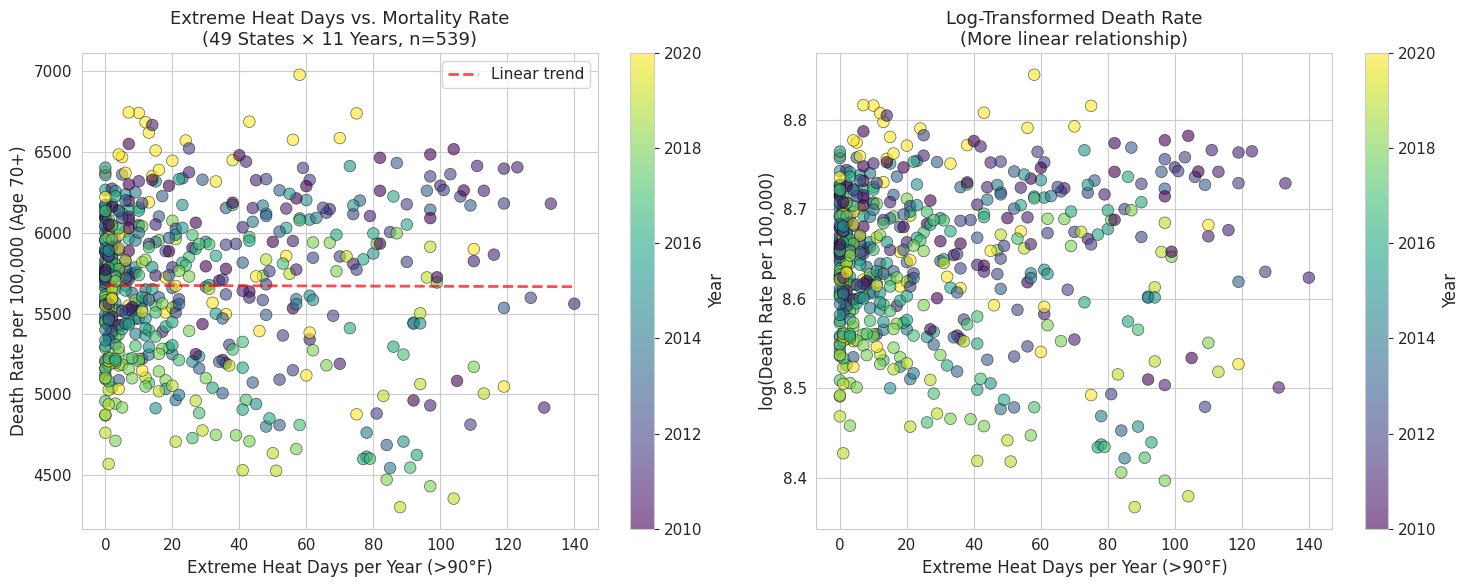

  ✓ 保存: fig1_scatter_heat_vs_mortality.png

生成图2：极端高温地图...


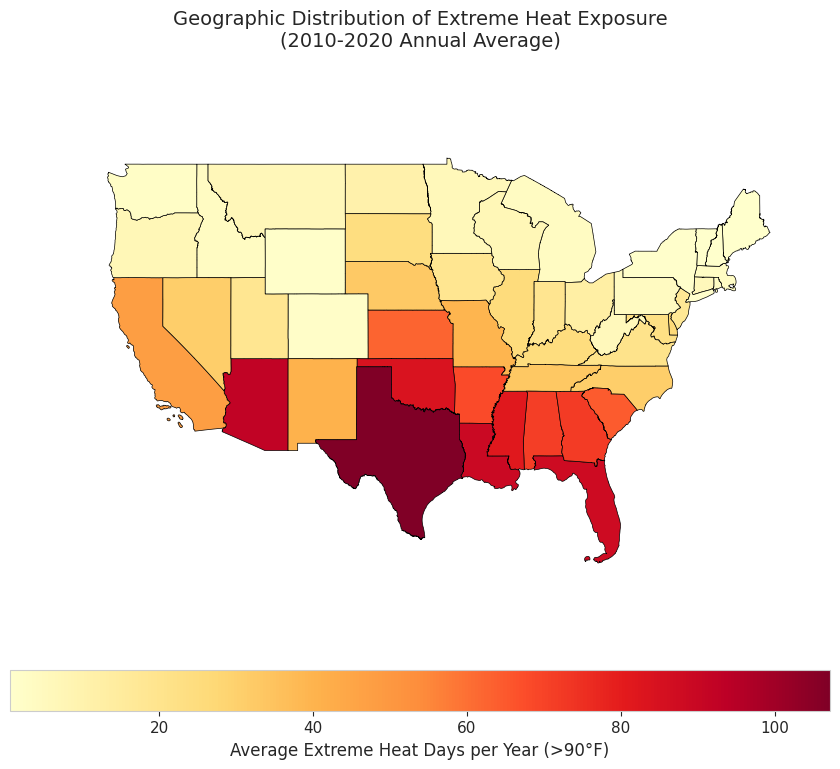

  ✓ 保存: fig2_map_extreme_heat_days.png

生成图3：死亡率地图...


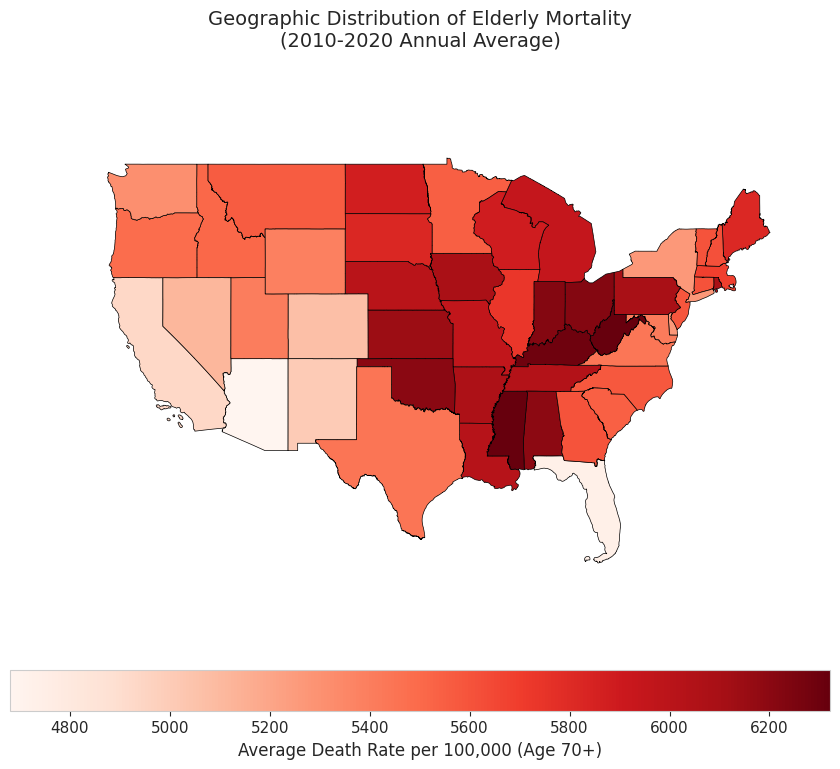

  ✓ 保存: fig3_map_mortality_rate.png

生成图4：季节性效应Forest Plot...


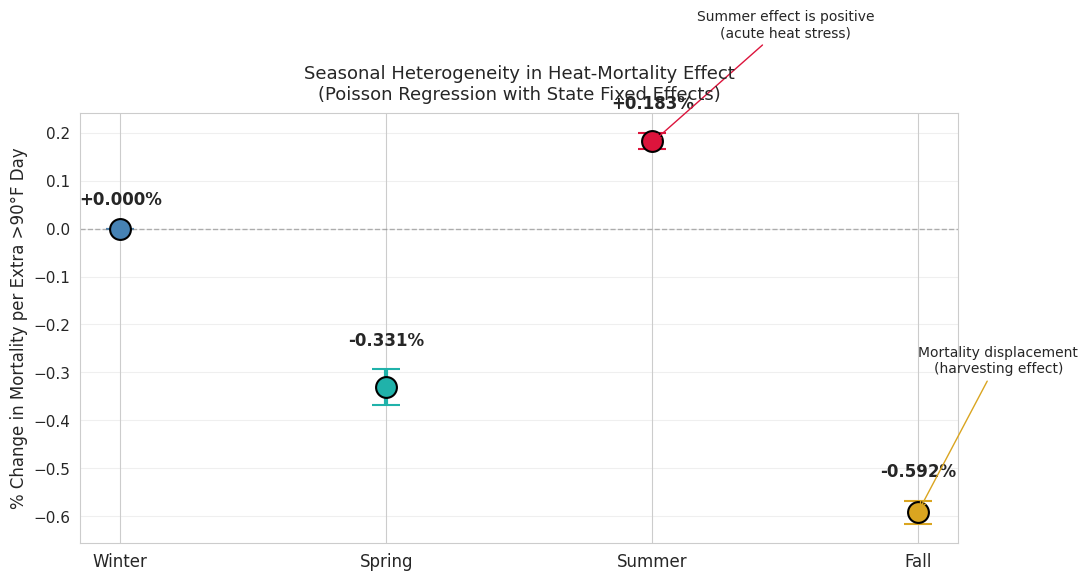

  ✓ 保存: fig4_seasonal_forest_plot.png

生成图5：州排名对比图...


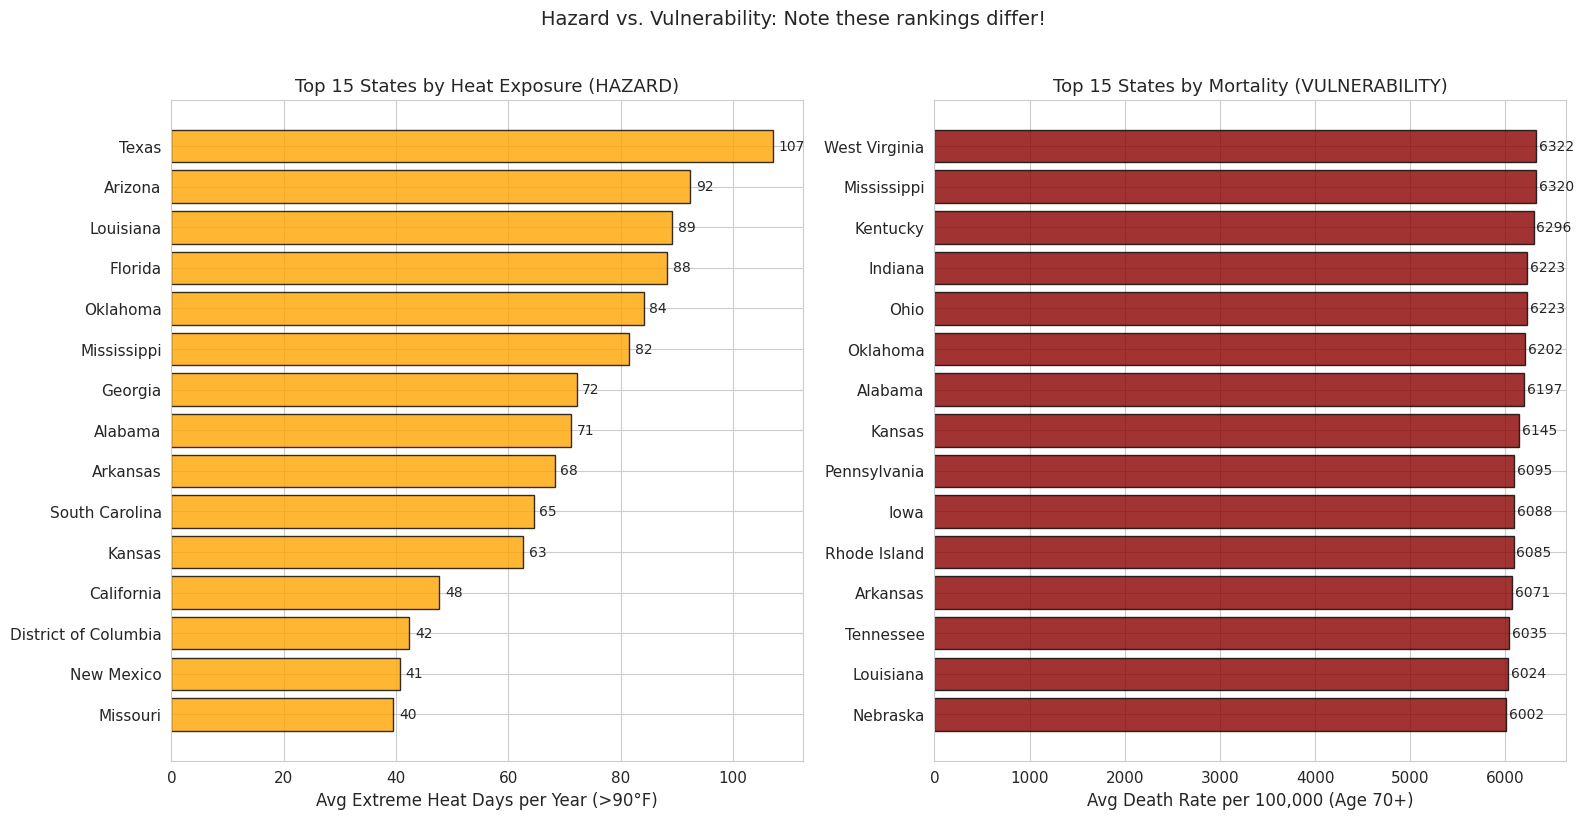

  ✓ 保存: fig5_state_rankings.png

生成图6：时间趋势图...


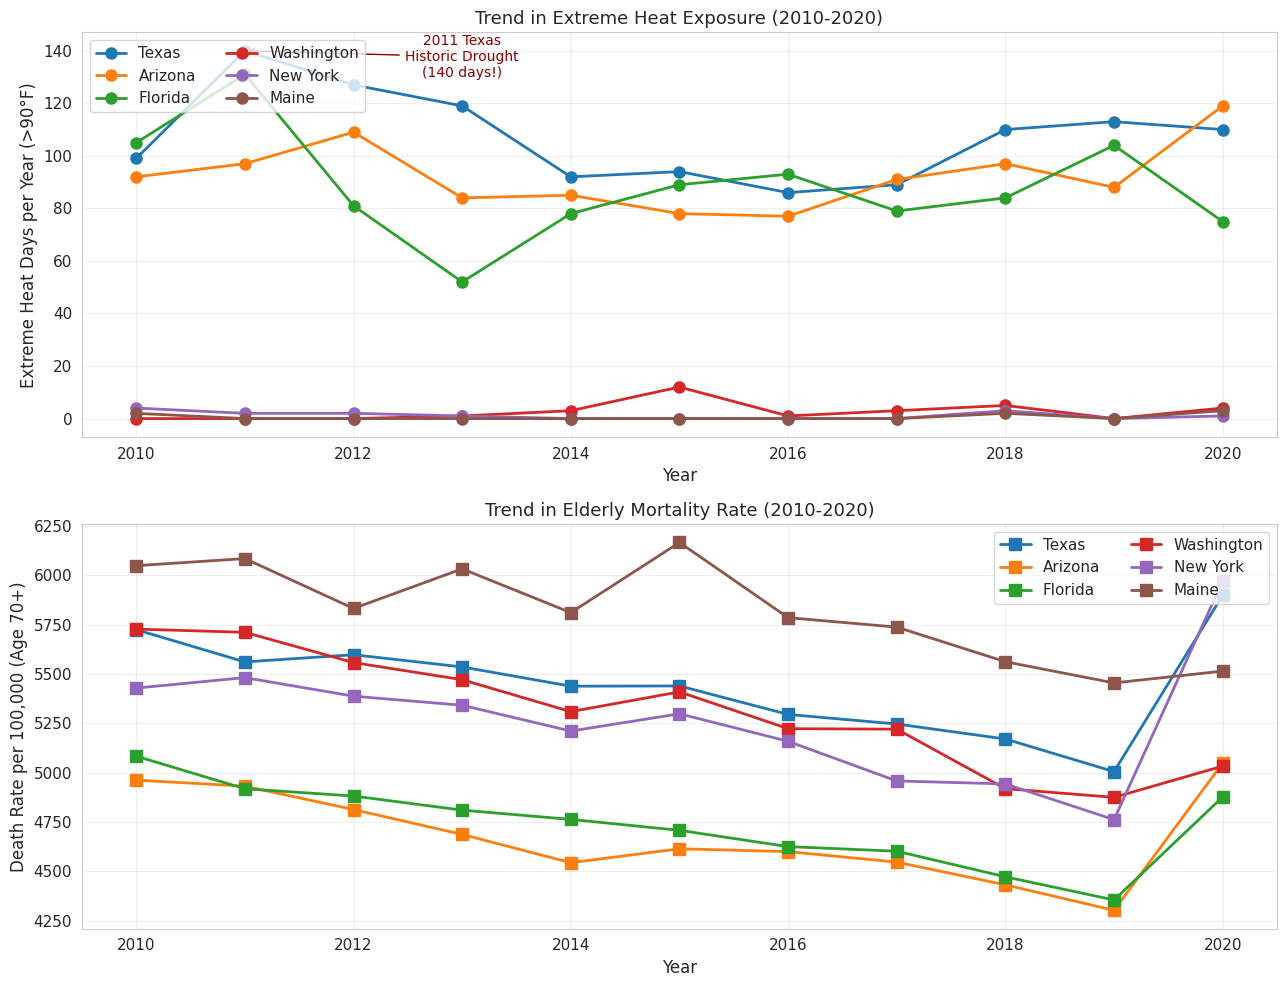

  ✓ 保存: fig6_time_trends.png

🎉 Step 5 可视化全部完成！

生成了6张图，全部保存在: /content/drive/MyDrive/DATA543_Project/figures/

图清单:
  fig1_scatter_heat_vs_mortality.png    (散点图)
  fig2_map_extreme_heat_days.png        (高温地图)
  fig3_map_mortality_rate.png           (死亡率地图)
  fig4_seasonal_forest_plot.png         (季节效应⭐)
  fig5_state_rankings.png               (州排名)
  fig6_time_trends.png                  (时间趋势)

下一步：Step 6 - Documentation（写文档给队友）


In [ ]:
# ===== Step 5: Visualization (6张专业级图) =====

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# 设置全局样式
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")

# === 路径设置 ===
DRIVE_ROOT = '/content/drive/MyDrive/DATA543_Project'
DATA_PROCESSED_DIR = f'{DRIVE_ROOT}/data_processed'
FIGURES_DIR = f'{DRIVE_ROOT}/figures'

# 加载数据
df_annual = pd.read_csv(f'{DATA_PROCESSED_DIR}/analysis_dataset_annual.csv')
df_monthly = pd.read_csv(f'{DATA_PROCESSED_DIR}/analysis_dataset_monthly.csv')
states_gdf = gpd.read_file(f'{DATA_PROCESSED_DIR}/us_states_geometry.shp')


# ============================================================
# 图1：散点图 - 高温天数 vs 死亡率
# ============================================================
print("生成图1：散点图...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 左图：原始数据散点
ax = axes[0]
scatter = ax.scatter(
    df_annual['extreme_heat_days_above_90F'],
    df_annual['death_rate_per_100k'],
    c=df_annual['Year'],
    cmap='viridis',
    alpha=0.6, s=70,
    edgecolors='black', linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_xlabel('Extreme Heat Days per Year (>90°F)')
ax.set_ylabel('Death Rate per 100,000 (Age 70+)')
ax.set_title('Extreme Heat Days vs. Mortality Rate\n(49 States × 11 Years, n=539)')

# 加趋势线
z = np.polyfit(df_annual['extreme_heat_days_above_90F'],
               df_annual['death_rate_per_100k'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, df_annual['extreme_heat_days_above_90F'].max(), 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, alpha=0.7, label='Linear trend')
ax.legend(loc='upper right')

# 右图：log变换后
ax = axes[1]
scatter = ax.scatter(
    df_annual['extreme_heat_days_above_90F'],
    df_annual['log_death_rate'],
    c=df_annual['Year'],
    cmap='viridis',
    alpha=0.6, s=70,
    edgecolors='black', linewidths=0.5
)
plt.colorbar(scatter, ax=ax, label='Year')
ax.set_xlabel('Extreme Heat Days per Year (>90°F)')
ax.set_ylabel('log(Death Rate per 100,000)')
ax.set_title('Log-Transformed Death Rate\n(More linear relationship)')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_scatter_heat_vs_mortality.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 保存: fig1_scatter_heat_vs_mortality.png")


# ============================================================
# 图2：美国地图 - 各州极端高温天数（11年平均）
# ============================================================
print("\n生成图2：极端高温地图...")

# 计算每州11年平均
state_avg = df_annual.groupby('State').agg(
    avg_heat_days=('extreme_heat_days_above_90F', 'mean'),
    avg_death_rate=('death_rate_per_100k', 'mean'),
    avg_population=('population_age70plus', 'mean')
).reset_index()

# 合并到geodataframe
states_with_data = states_gdf.merge(state_avg, on='State', how='left')

fig, ax = plt.subplots(figsize=(14, 8))
states_with_data.plot(
    ax=ax,
    column='avg_heat_days',
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': 'Average Extreme Heat Days per Year (>90°F)',
                 'shrink': 0.6, 'orientation': 'horizontal', 'pad': 0.05},
    missing_kwds={'color': 'lightgray', 'edgecolor': 'black',
                  'hatch': '///', 'label': 'No GRIDMET coverage'}
)
ax.set_xlim(-130, -65)
ax.set_ylim(20, 55)
ax.set_title('Geographic Distribution of Extreme Heat Exposure\n(2010-2020 Annual Average)',
             fontsize=14, pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_map_extreme_heat_days.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 保存: fig2_map_extreme_heat_days.png")


# ============================================================
# 图3：美国地图 - 老年人死亡率
# ============================================================
print("\n生成图3：死亡率地图...")

fig, ax = plt.subplots(figsize=(14, 8))
states_with_data.plot(
    ax=ax,
    column='avg_death_rate',
    cmap='Reds',
    edgecolor='black',
    linewidth=0.5,
    legend=True,
    legend_kwds={'label': 'Average Death Rate per 100,000 (Age 70+)',
                 'shrink': 0.6, 'orientation': 'horizontal', 'pad': 0.05},
    missing_kwds={'color': 'lightgray', 'edgecolor': 'black', 'hatch': '///'}
)
ax.set_xlim(-130, -65)
ax.set_ylim(20, 55)
ax.set_title('Geographic Distribution of Elderly Mortality\n(2010-2020 Annual Average)',
             fontsize=14, pad=15)
ax.axis('off')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_map_mortality_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 保存: fig3_map_mortality_rate.png")


# ============================================================
# 图4：季节性效应（Forest Plot - 你最重要的发现！）
# ============================================================
print("\n生成图4：季节性效应Forest Plot...")

# 用之前模型的结果（手动输入）
seasonal_data = {
    'Season': ['Winter', 'Spring', 'Summer', 'Fall'],
    'pct_change': [0.0000, -0.3312, 0.1827, -0.5920],
    'ci_lower':   [0.0000, -0.3686, 0.1655, -0.6157],
    'ci_upper':   [0.0000, -0.2938, 0.1999, -0.5684]
}
seasonal_df = pd.DataFrame(seasonal_data)

fig, ax = plt.subplots(figsize=(11, 6))

# 颜色：夏季正效应红色，其他蓝色
colors = ['steelblue', 'lightseagreen', 'crimson', 'goldenrod']

for i, row in seasonal_df.iterrows():
    err_lower = row['pct_change'] - row['ci_lower']
    err_upper = row['ci_upper'] - row['pct_change']

    ax.errorbar(
        i, row['pct_change'],
        yerr=[[err_lower], [err_upper]],
        fmt='o', markersize=15,
        capsize=10, capthick=3,
        color=colors[i], linewidth=3,
        markeredgecolor='black', markeredgewidth=1.5
    )

    # 标注数值
    ax.text(i, row['ci_upper'] + 0.05,
            f"{row['pct_change']:+.3f}%",
            ha='center', fontsize=12, fontweight='bold')

ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xticks(range(4))
ax.set_xticklabels(seasonal_df['Season'], fontsize=12)
ax.set_ylabel('% Change in Mortality per Extra >90°F Day', fontsize=12)
ax.set_title('Seasonal Heterogeneity in Heat-Mortality Effect\n(Poisson Regression with State Fixed Effects)',
             fontsize=13, pad=10)
ax.grid(axis='y', alpha=0.3)

# 加注释
ax.annotate('Summer effect is positive\n(acute heat stress)',
            xy=(2, 0.18), xytext=(2.5, 0.4),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='crimson'))
ax.annotate('Mortality displacement\n(harvesting effect)',
            xy=(3, -0.59), xytext=(3.3, -0.3),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='goldenrod'))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig4_seasonal_forest_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 保存: fig4_seasonal_forest_plot.png")


# ============================================================
# 图5：高温州 vs 低温州对比（条形图）
# ============================================================
print("\n生成图5：州排名对比图...")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 左图：高温天数排名前15
ax = axes[0]
top15_heat = state_avg.nlargest(15, 'avg_heat_days')
bars = ax.barh(top15_heat['State'], top15_heat['avg_heat_days'],
                color='orange', alpha=0.8, edgecolor='black')
ax.set_xlabel('Avg Extreme Heat Days per Year (>90°F)')
ax.set_title('Top 15 States by Heat Exposure (HAZARD)')
ax.invert_yaxis()
for i, (idx, row) in enumerate(top15_heat.iterrows()):
    ax.text(row['avg_heat_days'] + 1, i, f"{row['avg_heat_days']:.0f}",
            va='center', fontsize=10)

# 右图：死亡率排名前15
ax = axes[1]
top15_mort = state_avg.nlargest(15, 'avg_death_rate')
bars = ax.barh(top15_mort['State'], top15_mort['avg_death_rate'],
                color='darkred', alpha=0.8, edgecolor='black')
ax.set_xlabel('Avg Death Rate per 100,000 (Age 70+)')
ax.set_title('Top 15 States by Mortality (VULNERABILITY)')
ax.invert_yaxis()
for i, (idx, row) in enumerate(top15_mort.iterrows()):
    ax.text(row['avg_death_rate'] + 30, i, f"{row['avg_death_rate']:.0f}",
            va='center', fontsize=10)

plt.suptitle('Hazard vs. Vulnerability: Note these rankings differ!',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig5_state_rankings.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 保存: fig5_state_rankings.png")


# ============================================================
# 图6：时间趋势 - 6个代表州的多年变化
# ============================================================
print("\n生成图6：时间趋势图...")

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# 选择6个代表州：3热3冷
selected_states = ['Texas', 'Arizona', 'Florida', 'Washington', 'New York', 'Maine']

# 上图：极端高温天数趋势
ax = axes[0]
for state in selected_states:
    state_data = df_annual[df_annual['State']==state].sort_values('Year')
    ax.plot(state_data['Year'], state_data['extreme_heat_days_above_90F'],
            marker='o', label=state, linewidth=2, markersize=8)

ax.set_xlabel('Year')
ax.set_ylabel('Extreme Heat Days per Year (>90°F)')
ax.set_title('Trend in Extreme Heat Exposure (2010-2020)')
ax.legend(loc='upper left', ncol=2)
ax.grid(alpha=0.3)

# 标注2011年Texas高峰
tx_2011 = df_annual[(df_annual['State']=='Texas') & (df_annual['Year']==2011)].iloc[0]
ax.annotate(f"2011 Texas\nHistoric Drought\n({tx_2011['extreme_heat_days_above_90F']:.0f} days!)",
            xy=(2011, tx_2011['extreme_heat_days_above_90F']),
            xytext=(2013, 130),
            fontsize=10, ha='center', color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

# 下图：死亡率趋势
ax = axes[1]
for state in selected_states:
    state_data = df_annual[df_annual['State']==state].sort_values('Year')
    ax.plot(state_data['Year'], state_data['death_rate_per_100k'],
            marker='s', label=state, linewidth=2, markersize=8)

ax.set_xlabel('Year')
ax.set_ylabel('Death Rate per 100,000 (Age 70+)')
ax.set_title('Trend in Elderly Mortality Rate (2010-2020)')
ax.legend(loc='upper right', ncol=2)
ax.grid(alpha=0.3)

# 标注2020年COVID影响
ax.annotate('2020: COVID-19\nimpact visible',
            xy=(2020, 6500), xytext=(2017, 6800),
            fontsize=10, ha='center', color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred'))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_time_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✓ 保存: fig6_time_trends.png")


print("\n" + "="*70)
print("🎉 Step 5 可视化全部完成！")
print("="*70)
print(f"\n生成了6张图，全部保存在: {FIGURES_DIR}/")
print("\n图清单:")
print("  fig1_scatter_heat_vs_mortality.png    (散点图)")
print("  fig2_map_extreme_heat_days.png        (高温地图)")
print("  fig3_map_mortality_rate.png           (死亡率地图)")
print("  fig4_seasonal_forest_plot.png         (季节效应⭐)")
print("  fig5_state_rankings.png               (州排名)")
print("  fig6_time_trends.png                  (时间趋势)")
print("\n下一步：Step 6 - Documentation（写文档给队友）")